# 02 — Offline engine microbenchmarks

**Objective.** Characterize each inference engine without a server, a client or a scheduler in the loop, at
fixed batch sizes, as a controlled reference for the online results.

**Research question.** How fast does each engine process prompts (prefill) and generate tokens (decode) at
batch 1, 8 and 32, and where does each engine lead?

**Data.** `data/processed/offline_samples.csv`, campaign `offline/main` (Experiment A): every measured sample of
`llama-bench` (batch 1), `llama-batched-bench` (batch 8, 32) and `vllm bench latency` (batch 1, 8, 32), three
workload shapes, both models.

**Method and caveats.**
- Each engine is measured with its own tool, and the tools do not have identical scope: `llama-bench` and
  `llama-batched-bench` time forward passes only; `vllm bench latency` times `LLM.generate()`, which includes
  scheduling, input preparation and sampling. Small differences are therefore not engine differences.
- vLLM's decode rate is derived as (OSL − 1) / (full-run latency − median prefill-only latency) from two separate
  engine runs, so its spread understates the uncertainty.
- llama.cpp INT8 (Q8_0) streams about half the weight bytes of BF16; comparisons against it are not
  precision-controlled. The 1B INT8 offline job had not run when the HBM nodes were drained.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "02_offline_engine_benchmarks.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
samples = loaders.offline_samples()
offline = metrics.summarize_offline(samples[samples["benchmark"].isin(["batch1", "batched"])])
primary = offline[offline["model"] == MODEL]
display(table(primary.pivot_table(index=["workload_shape", "test", "batch"], columns="configuration_label",
                                  values="tok_s_mean", sort=False).reset_index()
              .rename(columns={"workload_shape": "Workload", "test": "Phase", "batch": "Batch"}),
              {c: "{:,.1f}" for c in primary["configuration_label"].unique()},
              caption=f"{registry.model_label(MODEL)}: tokens/s, mean over repetitions"))

Workload,Phase,Batch,llama.cpp · BF16,llama.cpp · INT8 (Q8_0),vLLM · BF16
512→512,decode,1,21.7,31.1,18.4
512→512,decode,8,88.7,126.7,138.4
512→512,decode,32,139.0,229.1,421.3
512→512,prefill,1,228.9,429.5,"1,236.2"
512→512,prefill,8,230.9,615.6,"1,321.0"
512→512,prefill,32,229.4,609.8,"1,411.7"
512→512,total,1,39.9,57.8,36.3
512→512,total,8,128.2,210.2,251.3
512→512,total,32,173.1,333.1,651.0
128→512,decode,1,22.2,31.6,18.4


## 1. Prompt processing (prefill)

Prefill is a large matrix product per layer and is compute-bound; it shows how much of each engine's matrix work
reaches the AMX units.

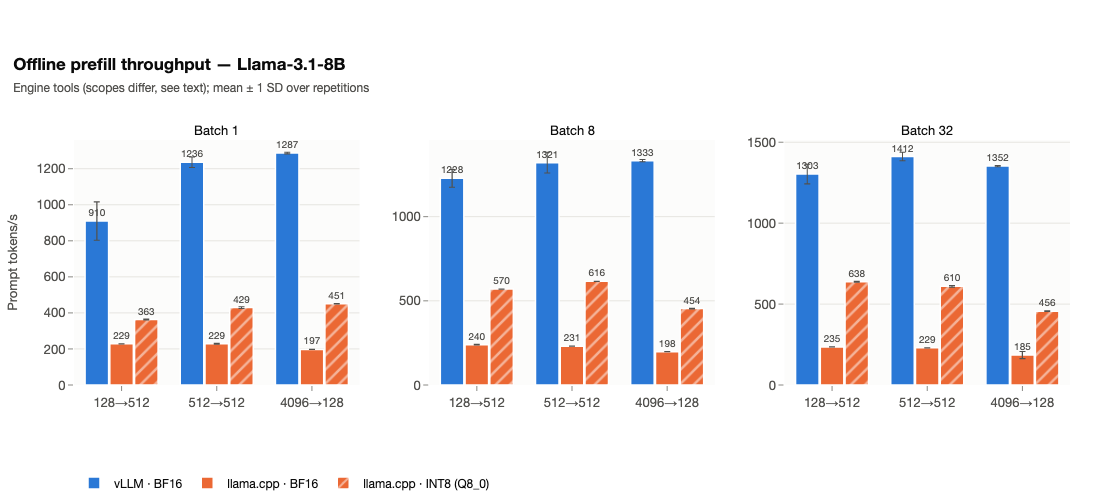

In [3]:
fig = plots.grouped_bars(primary[primary["test"] == "prefill"], x="workload_shape", y="tok_s_mean", error="tok_s_std",
                         facet="batch", facet_labels={1: "Batch 1", 8: "Batch 8", 32: "Batch 32"},
                         title=f"Offline prefill throughput — {registry.model_label(MODEL)}",
                         subtitle="Engine tools (scopes differ, see text); mean ± 1 SD over repetitions",
                         y_title="Prompt tokens/s")
fig.show()

In [4]:
bf16 = primary[primary["precision"] == "bf16"].pivot_table(index=["workload", "test", "batch"], columns="backend",
                                                            values="tok_s_mean")
bf16["vllm_over_llama_cpp"] = bf16["vllm"] / bf16["llama_cpp"]
pre = bf16.xs("prefill", level="test")["vllm_over_llama_cpp"]
dec = bf16.xs("decode", level="test")["vllm_over_llama_cpp"]
show(f"BF16 prefill, vLLM ÷ llama.cpp: {rng(pre, x)} across shapes and batch sizes. "
     f"BF16 decode at batch 1: {rng(dec.xs(1, level='batch'), x, nd=2)}; at batch 8: {rng(dec.xs(8, level='batch'), x)}; "
     f"at batch 32: {rng(dec.xs(32, level='batch'), x)}.")

BF16 prefill, vLLM ÷ llama.cpp: 4.0×–7.3× across shapes and batch sizes. BF16 decode at batch 1: 0.83×–0.89×; at batch 8: 1.4×–2.8×; at batch 32: 2.8×–4.9×.

**Interpretation.** vLLM prefills several times faster than llama.cpp at BF16 at every batch size, and neither
engine's prefill rate grows much with batch because prefill is already a large GEMM. This is consistent with
vLLM executing its BF16 GEMMs (and attention) on AMX tiles while llama.cpp's BF16 path has no AMX kernel and runs
on AVX-512-BF16. llama.cpp INT8 recovers part of the gap because its Q8_0 GEMMs with ≥ 2 rows do use AMX-INT8.

## 2. Token generation (decode)

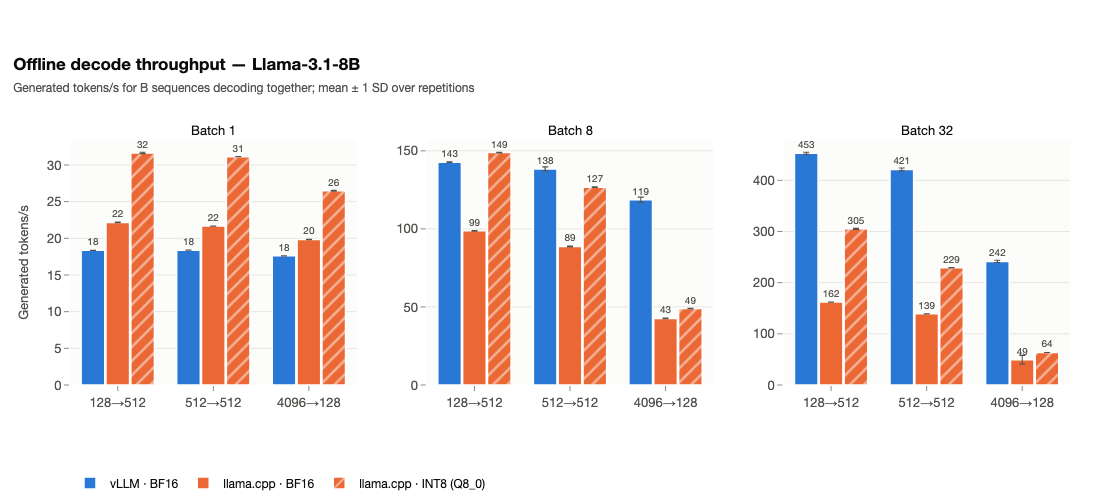

In [5]:
fig = plots.grouped_bars(primary[primary["test"] == "decode"], x="workload_shape", y="tok_s_mean", error="tok_s_std",
                         facet="batch", facet_labels={1: "Batch 1", 8: "Batch 8", 32: "Batch 32"},
                         title=f"Offline decode throughput — {registry.model_label(MODEL)}",
                         subtitle="Generated tokens/s for B sequences decoding together; mean ± 1 SD over repetitions",
                         y_title="Generated tokens/s")
fig.show()
export_figure(fig, "offline_decode_throughput", source=NOTEBOOK,
              caption="Offline decode tokens/s at batch 1, 8 and 32 for each engine (engine tools, scopes differ).")

In [6]:
d1 = primary[(primary["test"] == "decode") & (primary["batch"] == 1)].pivot_table(index="workload_shape",
                                                                                  columns="configuration_id",
                                                                                  values="tok_s_mean")
int8_vs_vllm = primary[(primary["test"] == "decode")].pivot_table(index=["workload_shape", "batch"],
                                                                  columns="configuration_id", values="tok_s_mean")
lead = int8_vs_vllm[int8_vs_vllm["llama_cpp_int8"] > int8_vs_vllm["vllm_bf16"]].reset_index()
show(f"Batch-1 decode: llama.cpp BF16 is {rng(d1['llama_cpp_bf16'] / d1['vllm_bf16'] - 1, pct)} faster than vLLM BF16; "
     f"llama.cpp INT8 {rng(d1['llama_cpp_int8'] / d1['vllm_bf16'] - 1, pct)} (half the weight bytes). "
     "Cells where llama.cpp INT8 out-decodes vLLM BF16: "
     + (", ".join(f"{r.workload_shape} at batch {r.batch}" for r in lead.itertuples()) or "none") + ".")

Batch-1 decode: llama.cpp BF16 is +13%–+21% faster than vLLM BF16; llama.cpp INT8 +50%–+72% (half the weight bytes). Cells where llama.cpp INT8 out-decodes vLLM BF16: 128→512 at batch 1, 128→512 at batch 8, 4096→128 at batch 1, 512→512 at batch 1.

**Interpretation.** Single-sequence decode streams all weights once per token and is limited by memory
bandwidth and per-token overhead; llama.cpp does this with less overhead and leads at batch 1 at matched
precision. As soon as several sequences decode together the order reverses: the weight read is amortized over the
batch, the step becomes matrix-heavy, and vLLM's batched decode grows much faster with batch than llama.cpp's.
llama.cpp INT8 out-decodes vLLM BF16 in the cells listed above (batch 1, and batch 8 on the shortest prompts),
which is a precision effect (half the bytes per step), not an engine effect.

## 3. Do offline and online measurements agree?

The online C=1 time to first token is a prefill of ISL tokens through the full server stack. If the offline tools
measure the same engine behaviour, ISL / TTFT should match the offline batch-1 prefill rate.

In [7]:
c1 = loaders.online_points(model=MODEL)
c1 = c1[(c1["concurrency"] == 1) & c1["workload"].isin(primary["workload"].unique())]
c1 = c1.assign(online_prefill_tok_s=c1["isl"] / c1["ttft_s_p50_mean"])
off1 = primary[(primary["test"] == "prefill") & (primary["batch"] == 1)][["configuration_id", "workload", "tok_s_mean"]]
agree = c1.merge(off1, on=["configuration_id", "workload"])
agree["online_over_offline"] = agree["online_prefill_tok_s"] / agree["tok_s_mean"]
display(table(agree[["configuration_label", "workload_shape", "tok_s_mean", "online_prefill_tok_s", "online_over_offline"]]
              .rename(columns={"configuration_label": "Configuration", "workload_shape": "Workload",
                               "tok_s_mean": "Offline prefill tok/s (batch 1)",
                               "online_prefill_tok_s": "Online ISL / TTFT at C=1", "online_over_offline": "Online ÷ offline"}),
              {"Offline prefill tok/s (batch 1)": "{:,.0f}", "Online ISL / TTFT at C=1": "{:,.0f}", "Online ÷ offline": "{:.2f}"}))

Configuration,Workload,Offline prefill tok/s (batch 1),Online ISL / TTFT at C=1,Online ÷ offline
vLLM · BF16,128→512,910,911,1.00
llama.cpp · BF16,128→512,229,219,0.96
llama.cpp · INT8 (Q8_0),128→512,363,287,0.79
vLLM · BF16,512→512,"1,236","1,219",0.99
llama.cpp · BF16,512→512,229,219,0.96
llama.cpp · INT8 (Q8_0),512→512,429,332,0.77
vLLM · BF16,4096→128,"1,287","1,286",1.00
llama.cpp · BF16,4096→128,197,195,0.99
llama.cpp · INT8 (Q8_0),4096→128,451,335,0.74


**Interpretation.** For the BF16 pair the online prefill rate reproduces the offline one within a few percent on
every shape, so the server, HTTP layer and client add little to a single request and the online BF16 comparison
measures the engines. llama.cpp INT8 is the exception: its server prefills noticeably slower than `llama-bench`
(ratio above). The cause was not isolated (the server and the benchmark tool batch the prompt differently); it
affects INT8's online TTFT, not the BF16 backend comparison.

## 4. Cross-check with the 1B model

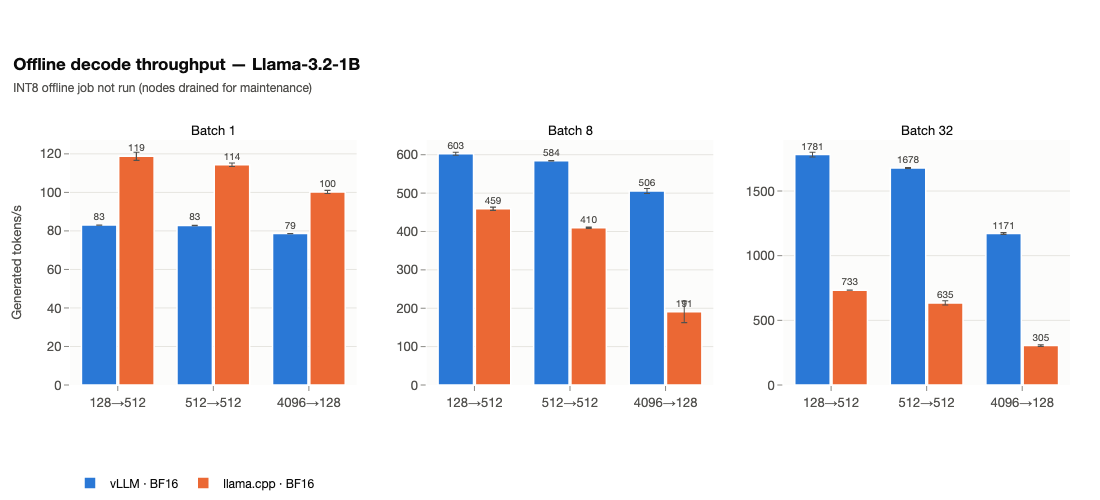

In [8]:
small = offline[offline["model"] != MODEL]
fig = plots.grouped_bars(small[small["test"] == "decode"], x="workload_shape", y="tok_s_mean", error="tok_s_std",
                         facet="batch", facet_labels={1: "Batch 1", 8: "Batch 8", 32: "Batch 32"},
                         title="Offline decode throughput — Llama-3.2-1B",
                         subtitle="INT8 offline job not run (nodes drained for maintenance)",
                         y_title="Generated tokens/s")
fig.show()

The 1B model shows the same crossover: llama.cpp leads single-sequence decode, vLLM leads batched decode and
prefill by a wide margin.

## Conclusions

- **Measured:** llama.cpp leads single-sequence decode at matched precision; vLLM leads prefill at every batch
  size and batched decode from batch 8 upward (BF16).
- **Interpretation:** llama.cpp is the leaner single-stream engine; vLLM's advantage appears wherever the work
  becomes matrix-heavy (prefill, batching), consistent with its AMX coverage at BF16.
- **Implication:** the offline results predict that the online ranking depends on concurrency — notebook 04
  tests this through the server stack.

## Limitations

- Tool scopes differ (forward passes vs `LLM.generate()`), so ratios close to 1 are not meaningful.
- Fixed-batch offline runs do not include continuous batching, request arrival or scheduling, which dominate
  online serving behaviour.
- `vllm bench throughput` (a vLLM-only reference, one sample per shape) is in the processed table
  (`benchmark == "throughput"`) but not compared, because llama.cpp has no equivalent tool.